<a href="https://colab.research.google.com/github/St1CkBSPL/PF174712/blob/main/Modele.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Moduł 2: Implementacja modeli

## Klasyfikacja tematyczna krótkich tekstów w języku polskim

W tym modelu implementujemy dwa podejścia do klasyfikacji tematycznej:

1. **Podejście klasyczne:** TF-IDF + SVM LinearSVC
2. **Podejście Transformer:** Fine-tuning modelu HerBERT (polski BERT)

Dane pochodzą z Modułu 1.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers[torch] accelerate evaluate datasets scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

# Wczytanie danych z poprzedniego modułu (Moduł 1)
print("Ładowanie plików:")
train_df = pd.read_csv("/content/drive/MyDrive/train.csv")
val_df = pd.read_csv("/content/drive/MyDrive/val.csv")
test_df = pd.read_csv("/content/drive/MyDrive/test.csv")

# Definicja kolumn
TEXT_COL = "text"              # oryginał dla Transformerów
CLEAN_COL = "text_clean"       # po lematyzacji dla TF-IDF
LABEL_COL = "label"            # 8 klas tematycznych

# Zabezpieczenie przed wartościami NaN
X_train_clean = train_df[CLEAN_COL].fillna("").values
X_val_clean = val_df[CLEAN_COL].fillna("").values
X_test_clean = test_df[CLEAN_COL].fillna("").values

y_train = train_df[LABEL_COL].values
y_val = val_df[LABEL_COL].values
y_test = test_df[LABEL_COL].values

print(f"Dane wczytane poprawnie! Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
Ładowanie plików:
Dane wczytane poprawnie! Train: 28000, Val: 4000, Test: 8001



Trening: SVM (LinearSVC)
Accuracy (val): 0.6787 | F1-score (val): 0.6787

Trening: Naive Bayes
Accuracy (val): 0.6835 | F1-score (val): 0.6834

Trening: Logistic Regression
Accuracy (val): 0.6890 | F1-score (val): 0.6891

Najlepszy model klasyczny to: Logistic Regression
Raport z wyników (Logistic Regression) na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.70      0.69      0.69      1008
           1       0.61      0.65      0.63       959
           2       0.72      0.75      0.73      1165
           3       0.67      0.68      0.68      1012
           4       0.72      0.61      0.66       790
           5       0.70      0.68      0.69       997
           6       0.74      0.72      0.73      1034
           7       0.59      0.63      0.61      1036

    accuracy                           0.68      8001
   macro avg       0.68      0.68      0.68      8001
weighted avg       0.68      0.68      0.68      8001



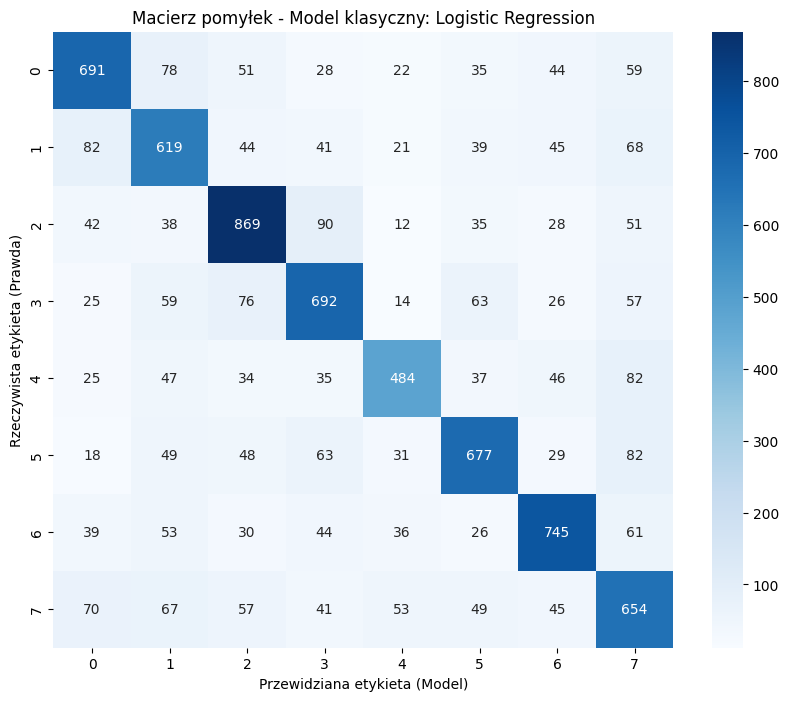

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

# Wektoryzacja tekstu
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

# Zdefiniowanie modeli do przetestowania
classifiers = {
    "SVM (LinearSVC)": LinearSVC(random_state=42, dual=False),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

classic_results = {}

for name, clf in classifiers.items():
    print(f"\nTrening: {name}")
    clf.fit(X_train_tfidf, y_train)
    y_val_pred = clf.predict(X_val_tfidf)

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="weighted")

    classic_results[name] = {
        "model": clf,
        "val_f1": f1
    }
    print(f"Accuracy (val): {acc:.4f} | F1-score (val): {f1:.4f}")

# Wybór najlepszego z klasyfikatorów do ewaluacji na zbiorze testowym
best_classic_name = max(classic_results, key=lambda x: classic_results[x]["val_f1"])
best_classic = classic_results[best_classic_name]["model"]

print(f"\nNajlepszy model klasyczny to: {best_classic_name}")
y_pred_classic = best_classic.predict(X_test_tfidf)

classic_test_acc = accuracy_score(y_test, y_pred_classic)
classic_test_f1 = f1_score(y_test, y_pred_classic, average="weighted")

print(f"Raport z wyników ({best_classic_name}) na zbiorze testowym:")
print(classification_report(y_test, y_pred_classic))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred_classic)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Macierz pomyłek - Model klasyczny: {best_classic_name}')
plt.xlabel('Przewidziana etykieta (Model)')
plt.ylabel('Rzeczywista etykieta (Prawda)')
plt.show()

In [4]:
!pip install transformers[torch] accelerate evaluate

Ładowanie Tokenizera: 


config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Ewaluacja na zbiorze testowym:



 WYNIKI MODELU TRANSFORMER (HerBERT)
              precision    recall  f1-score   support

           0       0.74      0.77      0.76      1008
           1       0.76      0.81      0.78       959
           2       0.84      0.84      0.84      1165
           3       0.78      0.77      0.77      1012
           4       0.75      0.77      0.76       790
           5       0.77      0.76      0.77       997
           6       0.85      0.80      0.82      1034
           7       0.74      0.71      0.73      1036

    accuracy                           0.78      8001
   macro avg       0.78      0.78      0.78      8001
weighted avg       0.78      0.78      0.78      8001



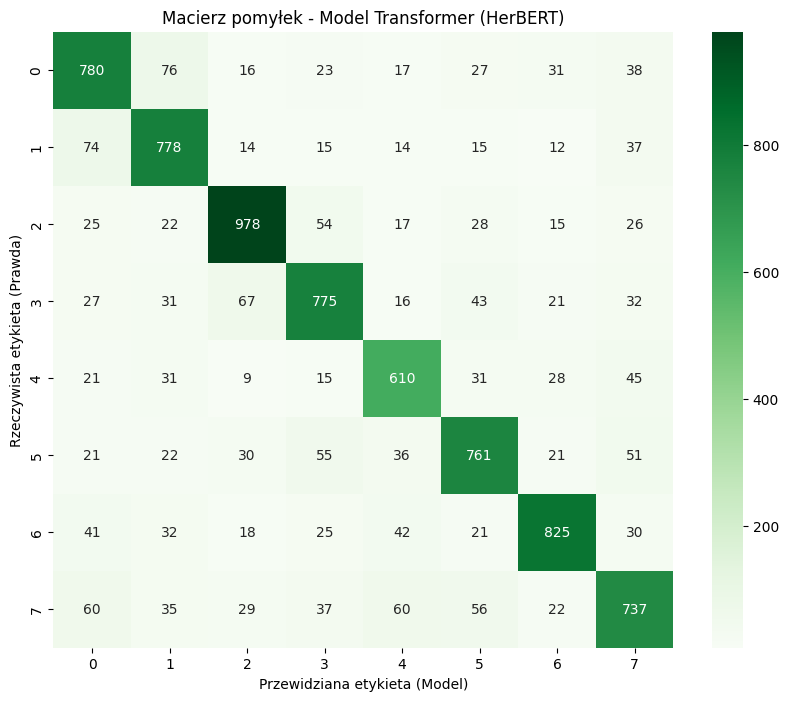

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import precision_recall_fscore_support

model_name = "allegro/herbert-base-cased"
print("Ładowanie Tokenizera: ")
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples[TEXT_COL], padding="max_length", truncation=True, max_length=64)

# Zmiana formatu z pandas.DataFrame na Dataset HuggingFace
train_dataset = Dataset.from_pandas(train_df[[TEXT_COL, LABEL_COL]])
val_dataset = Dataset.from_pandas(val_df[[TEXT_COL, LABEL_COL]])
test_dataset = Dataset.from_pandas(test_df[[TEXT_COL, LABEL_COL]])

print("Tokenizacja: ")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

print("Ładowanie modelu HerBERT (dla 8 klas): ")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=8)

training_args = TrainingArguments(
    output_dir="./herbert_wyniki",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("\nTrenowanie modelu HerBERT:")
trainer.train()

print("\nEwaluacja na zbiorze testowym:")
predictions = trainer.predict(tokenized_test)
y_pred_transformer = np.argmax(predictions.predictions, axis=1)

trans_test_acc = predictions.metrics.get("test_accuracy", accuracy_score(y_test, y_pred_transformer))
trans_test_f1 = predictions.metrics.get("test_f1", f1_score(y_test, y_pred_transformer, average="weighted"))

print("\n WYNIKI MODELU TRANSFORMER (HerBERT)")
print(classification_report(y_test, y_pred_transformer))

cm_trans = confusion_matrix(y_test, y_pred_transformer)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Greens')
plt.title('Macierz pomyłek - Model Transformer (HerBERT)')
plt.xlabel('Przewidziana etykieta (Model)')
plt.ylabel('Rzeczywista etykieta (Prawda)')
plt.show()

In [6]:
# Zapis predykcji modeli bezpośrednio na Dysk Google
results_df = test_df.copy()
results_df["pred_classic"] = y_pred_classic
results_df["pred_transformer"] = y_pred_transformer
results_df.to_csv("/content/drive/MyDrive/test_predictions.csv", index=False)

# Zapis słownika z podsumowaniem wyników bezpośrednio na Dysk Google
summary = {
    "classic_name": best_classic_name,
    "classic_accuracy": classic_test_acc,
    "classic_f1": classic_test_f1,
    "transformer_name": "HerBERT",
    "transformer_accuracy": trans_test_acc,
    "transformer_f1": trans_test_f1,
}

with open("/content/drive/MyDrive/results_summary.pkl", "wb") as f:
    pickle.dump(summary, f)

print("Sukces! Pliki test_predictions.csv oraz results_summary.pkl zostały bezpiecznie zapisane na Dysku Google.")

Sukces! Pliki test_predictions.csv oraz results_summary.pkl zostały bezpiecznie zapisane na Dysku Google.
